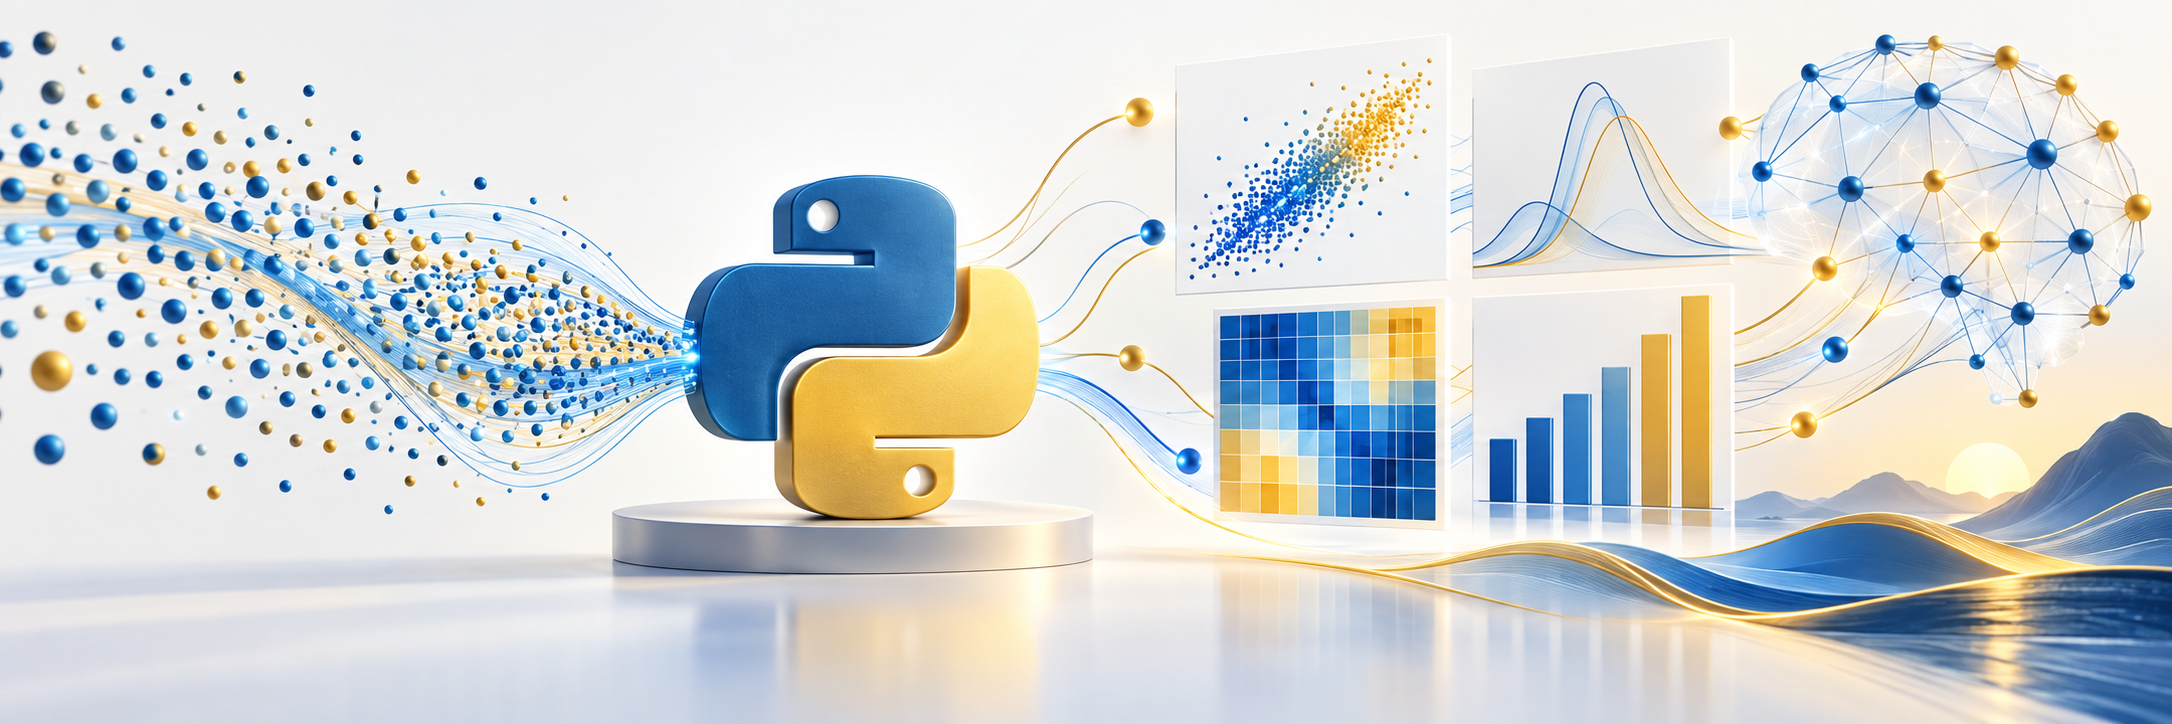

## IA001 — Análise e Visualização de Dados com Python e Ferramentas Assistidas por IA

## Atividade 01 — Proposta de análise visual de dados

**Objetivo:** escolher um conjunto de dados, realizar uma exploração inicial e propor perguntas que possam orientar uma ferramenta de visualização.

**Produto da atividade:** este notebook preenchido, com respostas, código executado, estatísticas, gráficos e referências.


## IA001 — Análise e Visualização de Dados com Python e Ferramentas Assistidas por IA

## Atividade 02 — Dashboard interativo com Streamlit

**Objetivo:** dar continuidade à Atividade 01, transformando a proposta de análise visual em um dashboard que permita explorar os dados e investigar as perguntas do grupo.

Trabalhem no mesmo grupo (até 3 integrantes) e utilizem o conjunto de dados da atividade anterior. Se precisarem alterar os dados ou as perguntas, justifiquem brevemente.


### O que desenvolver

Criem uma aplicação em **Streamlit** voltada ao público identificado na Atividade 01. O dashboard deve:

- Investigar **pelo menos duas perguntas** propostas na atividade anterior.
- Conter **pelo menos três visualizações**, utilizando **ao menos duas** das bibliotecas estudadas: Altair, Plotly, Seaborn, Matplotlib ou Folium. Escolham as bibliotecas de acordo com os dados e as perguntas; mapas são opcionais quando houver informação geográfica. Streamlit é a estrutura da aplicação e não conta como uma das duas bibliotecas de visualização.
- Oferecer **pelo menos dois controles interativos**, como seleção de categorias, período ou região, que atualizem as visualizações pertinentes. Informem quando uma seleção não produzir dados.
- Apresentar títulos, rótulos, unidades, fonte dos dados e textos curtos que ajudem o usuário a interpretar os resultados.

Vocês podem adaptar os exemplos dos notebooks da aula. Confiram se os filtros e os cálculos produzem resultados coerentes com os dados.


### Entrega

Entreguem uma pasta ou arquivo ZIP com:

1. A aplicação (`app.py` e eventuais arquivos auxiliares).
2. Um `requirements.txt` e instruções de instalação e execução em um `README.md`.
3. Os dados necessários, quando o compartilhamento for permitido, ou instruções reproduzíveis para obtê-los.
4. Este notebook preenchido com o registro breve abaixo.

A aplicação deve executar localmente. A publicação na internet é opcional. Antes de entregar, testem a execução seguindo o próprio README e experimentem diferentes combinações dos filtros.

**Critérios de qualidade:** continuidade com a proposta, adequação dos gráficos às perguntas, funcionamento das interações, clareza da interface e possibilidade de reproduzir a execução.


### Registro do grupo

**Grupo e integrantes:** Prevenção do Câncer de Colo e Mama

| Nome completo | Participação nesta atividade |
|---|---|
| Yuri Espinosa Pires | Estrutura do app (`app.py`), carregamento e cache dos dados, Pergunta 5 (dispersão recurso de radioterapia x exames) e Pergunta 6 (heatmap de infraestrutura), uniformização dos dados e elaboração das perguntas. |
| Gabriel Fernandes Leal | Mapa coroplético por estado (Plotly), incluindo o carregamento do GeoJSON dos estados brasileiros e o seletor de indicador, formualação de novas perguntas e visualização unificada de todos os indicadores |

**Perguntas da Atividade 01 contempladas pelo dashboard:** o dashboard não repete diretamente as 4 perguntas originais da Atividade 01 (elas já haviam sido exploradas nos gráficos estáticos do notebook anterior). Em vez disso, decidimos usar os mesmos dados e o mesmo recorte para investigar três perguntas novas, adequadas ao formato interativo de um dashboard:

1. Estados que recebem mais recurso de radioterapia (PERSUS) também apresentam maior volume de rastreamento (exames citopatológicos)? — cruza dois indicadores que a Atividade 01 nunca havia comparado diretamente.
2. A infraestrutura especializada (hospitais de alta complexidade, hospitais PERSUS e laboratórios QualiCito) se expandiu de forma uniforme entre os estados, ou de forma concentrada? — generaliza a pergunta 4 da Atividade 01 (que olhava só SDM/SRC) para os 3 indicadores de infraestrutura.
3. O rastreamento (exames citopatológicos e mamografias) já se recuperou do choque de 2020, e todas as regiões se recuperaram no mesmo ritmo? — as demais views mostram onde e quanto, mas não a trajetória temporal dos indicadores de fluxo; esta usa o ano de 2019 (último ano completo antes da pandemia) como base.

Além disso, adicionamos um mapa coroplético (View 1) que não responde a uma pergunta específica da Atividade 01, mas dá suporte visual a todas elas, permitindo explorar a distribuição geográfica de qualquer um dos 8 indicadores do dataset.

**Visualizações e bibliotecas utilizadas — justifiquem brevemente as escolhas:**

- **View 1 — Mapa coroplético por estado (Plotly, `px.choropleth_map`):** escolhemos Plotly porque ele lida bem com geometrias (GeoJSON) e produz um mapa interativo com hover, algo que nenhuma das outras bibliotecas do curso oferece prontamente para coropléticos. Inicialmente o mapa usava `animation_frame="ano"` para animar a série temporal, mas isso tornava a construção do gráfico ~10x mais lenta (o Plotly revalida o GeoJSON contra cada quadro); trocamos por um seletor de ano na barra lateral, o que também deixou a navegação mais previsível para o usuário.
- **View 2 — Dispersão recurso x exames (Altair, `mark_circle`):** Altair tem uma API declarativa muito direta para seleção interativa vinculada à legenda (`selection_point(bind="legend")`), o que permite destacar uma região clicando nela — um recurso que usamos para investigar visualmente se a relação entre as duas variáveis muda por região.
- **View 3 — Heatmap de infraestrutura (Altair, `mark_rect` + `facet`):** optamos por um heatmap porque a matriz estado x ano é o formato mais direto para mostrar presença/ausência de uma infraestrutura ao longo do tempo para as 27 UFs simultaneamente. Inicialmente combinamos os 3 indicadores em um único heatmap com um "score" de 0 a 3, mas isso escondia qual infraestrutura exatamente cada estado tinha; trocamos por 3 painéis lado a lado (`facet`), um por indicador, para comparar o ritmo de expansão de cada tipo separadamente.

- **View 4 — Série temporal indexada (Altair, `mark_line` + `mark_rule`):** escolhemos um gráfico de linhas porque a pergunta é sobre trajetória ao longo dos anos, e o eixo Y foi indexado em 2019 = 100 para que regiões de tamanhos muito diferentes (por exemplo, Sudeste e Norte) possam ser comparadas na mesma escala; uma linha tracejada em 100 marca o nível pré-pandemia. Um seletor alterna entre exames citopatológicos e mamografias, e cartões de métrica mostram a situação de cada região no último ano do período em relação a 2019. O índice é calculado sobre a série completa das regiões selecionadas, para que a base de 2019 exista mesmo quando o filtro de período a exclui.


**Como o público escolhido pode usar os filtros para investigar uma pergunta?** Um gestor de saúde estadual interessado em saber se o investimento em radioterapia do seu estado está acompanhado de um bom volume de rastreamento pode: (1) selecionar seu estado indiretamente observando o ponto correspondente na View 2, usando o filtro de região da barra lateral para isolar sua macrorregião e reduzir a quantidade de pontos na tela; (2) clicar na legenda da região para destacar só os estados dela; (3) passar o mouse sobre o ponto do seu estado para ver o valor exato de recurso recebido e exames realizados naquele ano; (4) comparar com a View 3 para checar se o mesmo estado também tem as 3 infraestruturas especializadas habilitadas, montando um diagnóstico mais completo antes de decidir onde priorizar investimento; (5) na View 4, ver se a sua região já voltou ao nível de rastreamento de 2019 e alternar entre exames e mamografias para checar se o padrão se repete.

**Um resultado observado e uma limitação da análise:** Na View 2, a correlação entre recurso de radioterapia e volume de exames citopatológicos (133 pares estado-ano com recurso > 0) é de **0,71**, estados mais financiados em radioterapia também tendem a rastrear mais. Na View 3, a cobertura de infraestrutura em 2025 não é uniforme: `hosp_alta_compl` e `lab_qualicito` estão em quase todos os estados (27/27 e 26/27), mas `hosp_persus` só em 23/27, o gargalo mais visível hoje. Limitação: os dados não têm população, então os números são volumes brutos, não taxas por habitante, e correlação não implica causalidade. Na View 4 (exames citopatológicos, 2025 em relação a 2019), apenas Norte (índice 128) e Sudeste (101) estão em ou acima do nível pré-pandemia; Nordeste (96), Centro-Oeste (95) e Sul (91) ainda estão abaixo, e o Sul, região de maior cobertura, é a mais distante da linha de base. Como o índice é relativo a 2019, uma região que partia de um volume baixo pode ter variação percentual grande sem que o volume absoluto seja alto (o volume absoluto aparece no tooltip).

**Mudanças em relação à proposta inicial, se houver:** Mudamos o foco das perguntas investigadas no dashboard: em vez de reimplementar interativamente as 4 perguntas originais da Atividade 01 (o que resultaria em gráficos quase idênticos aos já produzidos no notebook anterior), formulamos 2 perguntas novas (recurso x rastreamento, e uniformidade da expansão de infraestrutura) que exploram relações entre indicadores ainda não comparados, aproveitando melhor a interatividade do Streamlit. Depois, acrescentamos uma terceira pergunta (View 4, evolução do rastreamento em relação a 2019) para cobrir a dimensão temporal dos indicadores de fluxo, que as demais views não mostravam. Também incorporei o mapa coroplético desenvolvido pelo Gabriel como uma das visualizações, elevando o total de bibliotecas usadas para duas (Plotly + Altair), ele se juntou nessa entrega comigo para formamos um grupo.

**Uso de IA e referências:**

| Ferramenta/modelo, se informado | Pedido ou tarefa | O que foi aproveitado | Como o grupo verificou ou corrigiu a resposta? |
|---|---|---|---|
| Claude (Sonnet) | Brainstorm de ideias para as views 2 e 3 do dashboard e revisão de código | Serviu como base de insumos para nos auxiliar em pensar e validar novas ideias sobre o trabalho, além de apontar e auxiliar no merge, codificação e identação do projeto. | Cada versão do `app.py` foi executada localmente com `streamlit run` e testada com `python -m py_compile`/execução direta do script antes de aceitar sugestões, os apoios em questões estatisticas foram recalculados diretamente sobre os CSVs antes de serem escritos aqui, em vez de aceitos por afirmação da IA |